Problem Statement:

The objective of this project is to analyze Indian Railway data and extract meaningful insights such as train routes, source stations, destination stations, distance covered, and train frequency using Python.

# Import Libraries

In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

# Read Dataset

In [2]:
rail = pd.read_csv("trains.csv")

# Display Dataset

In [3]:
rail.head() #First 5 Records

,Unnamed: 0,Train_Name,Train_Number,Source,Destination,Distance,Total_Time,Departure,Arrival
0,0,Jammu Tawi Udhampur Special,4601,JAMMU TAWI,UDHAMPUR,53.0,0 days 01:35:00,10:40:00,12:15:00
1,1,JAT UDAHMPUR DMU,4603,JAMMU TAWI,UDHAMPUR,53.0,0 days 01:35:00,16:15:00,17:50:00
2,3,UDHAMPUR JAMMUTAWI DMU,4604,UDHAMPUR,JAMMU TAWI,53.0,0 days 01:30:00,18:20:00,19:50:00
3,4,Mumbai BandraT-Bikaner SF Special,4728,MUMBAI BANDRA TERMINUS,BIKANER JN,1212.0,0 days 21:55:00,14:35:00,12:30:00
4,5,Sirsa - Hisar Passenger Special,4741,Sirsa,Hisar,82.0,0 days 01:35:00,22:50:00,0:25:00


In [4]:
rail.tail() #Last 5 Records

,Unnamed: 0,Train_Name,Train_Number,Source,Destination,Distance,Total_Time,Departure,Arrival
5202,5203,New Delhi Palwal Ladies Special,64492,NEW DELHI,PALWAL,56.0,0 days 01:30:00,17:50:00,19:20:00
5203,5204,Visakhapatnam Rajahmundry Pass,67296,VISHAKAPATNAM,RAJAMUNDRY,201.0,0 days 05:15:00,18:10:00,23:25:00
5204,5205,Madgaon Karwar Passenger,70101,MADGAON,KARWAR,82.0,0 days 01:20:00,19:00:00,20:20:00
5205,5206,Danapur Giridih Express,83112,DANAPUR,Giridih,298.0,0 days 09:30:00,19:00:00,4:30:00
5206,5207,Tribeni Link Express,84369,BARWADIH JN,BAREILLY,862.0,0 days 21:00:00,15:30:00,12:30:00


In [5]:
rail.shape #Shape of Dataset

(5207, 9)

In [6]:
rail.columns #Column Names

Index(['Unnamed: 0', 'Train_Name', 'Train_Number', 'Source', 'Destination',
       'Distance', 'Total_Time', 'Departure', 'Arrival'],
      dtype='object')

# DATA CLEANING


In [7]:
# Remove Unnamed Column 

In [8]:
rail = rail.drop("Unnamed: 0", axis=1)
rail.head()

,Train_Name,Train_Number,Source,Destination,Distance,Total_Time,Departure,Arrival
0,Jammu Tawi Udhampur Special,4601,JAMMU TAWI,UDHAMPUR,53.0,0 days 01:35:00,10:40:00,12:15:00
1,JAT UDAHMPUR DMU,4603,JAMMU TAWI,UDHAMPUR,53.0,0 days 01:35:00,16:15:00,17:50:00
2,UDHAMPUR JAMMUTAWI DMU,4604,UDHAMPUR,JAMMU TAWI,53.0,0 days 01:30:00,18:20:00,19:50:00
3,Mumbai BandraT-Bikaner SF Special,4728,MUMBAI BANDRA TERMINUS,BIKANER JN,1212.0,0 days 21:55:00,14:35:00,12:30:00
4,Sirsa - Hisar Passenger Special,4741,Sirsa,Hisar,82.0,0 days 01:35:00,22:50:00,0:25:00


In [9]:
# Rename Required Columns 

In [10]:
rail.rename(columns={"Train_Name":"TrainName","Train_Number":"TrainNumber","Total_Time":"TotalTime"}, inplace=True)
rail.head()

,TrainName,TrainNumber,Source,Destination,Distance,TotalTime,Departure,Arrival
0,Jammu Tawi Udhampur Special,4601,JAMMU TAWI,UDHAMPUR,53.0,0 days 01:35:00,10:40:00,12:15:00
1,JAT UDAHMPUR DMU,4603,JAMMU TAWI,UDHAMPUR,53.0,0 days 01:35:00,16:15:00,17:50:00
2,UDHAMPUR JAMMUTAWI DMU,4604,UDHAMPUR,JAMMU TAWI,53.0,0 days 01:30:00,18:20:00,19:50:00
3,Mumbai BandraT-Bikaner SF Special,4728,MUMBAI BANDRA TERMINUS,BIKANER JN,1212.0,0 days 21:55:00,14:35:00,12:30:00
4,Sirsa - Hisar Passenger Special,4741,Sirsa,Hisar,82.0,0 days 01:35:00,22:50:00,0:25:00


In [11]:
# Performing NULL operation

In [12]:
rail.isna().sum()

TrainName       1
TrainNumber     0
Source          0
Destination     0
Distance       15
TotalTime      15
Departure      15
Arrival        15
dtype: int64

In [13]:
rail = rail.dropna().reset_index(drop = True)

In [14]:
rail.isna().sum()

TrainName      0
TrainNumber    0
Source         0
Destination    0
Distance       0
TotalTime      0
Departure      0
Arrival        0
dtype: int64

In [15]:
rail.duplicated().sum()

np.int64(0)

In [16]:
# Check The Datatypes

In [17]:
rail.dtypes

TrainName       object
TrainNumber     object
Source          object
Destination     object
Distance       float64
TotalTime       object
Departure       object
Arrival         object
dtype: object

# UNIVARIATE ANALYSIS

(Analysis using one column)

In [18]:
# Q1. How many trains are available?

In [19]:
print("Total Trains =",len(rail))

Total Trains = 5191


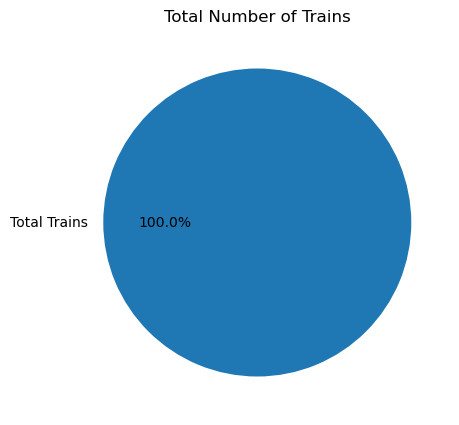

In [20]:
train_count = len(rail)

plt.figure(figsize=(5,5))
plt.pie([train_count],labels=["Total Trains"],autopct="%1.1f%%")
plt.title("Total Number of Trains")
plt.show()

In [21]:
# Q2. Which train covers maximum distance?

In [22]:
rail[rail["Distance"]==rail["Distance"].max()]

,TrainName,TrainNumber,Source,Destination,Distance,TotalTime,Departure,Arrival
1560,KANNIYAKUMARI - DIBRUGARH Vivek Exp,15905,KANYAKUMARI,DIBRUGARH,4279.0,3 days 13:30:00,14:00:00,3:30:00


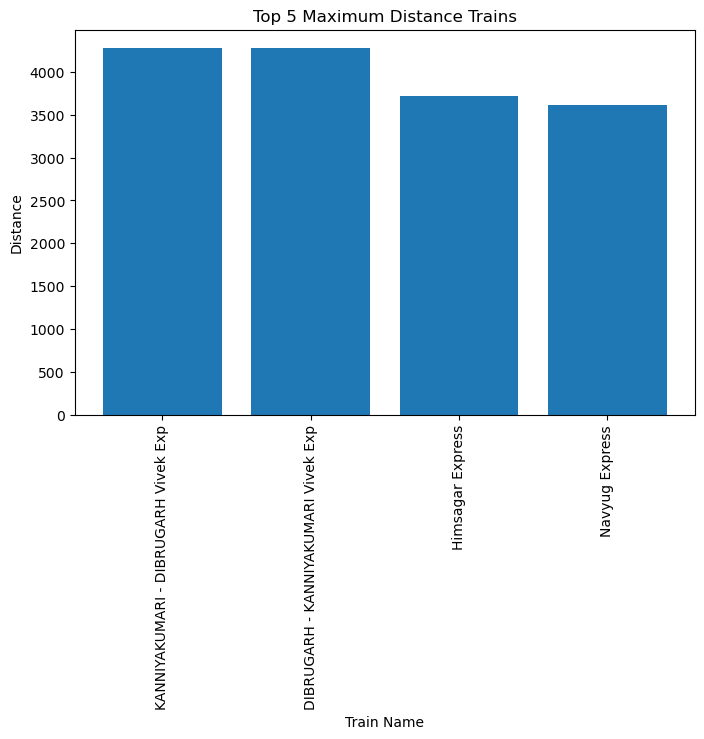

In [23]:
max_train = rail.nlargest(5,"Distance")

plt.figure(figsize=(8,5))
plt.bar(max_train["TrainName"],max_train["Distance"])
plt.xticks(rotation=90)
plt.title("Top 5 Maximum Distance Trains")
plt.xlabel("Train Name")
plt.ylabel("Distance")
plt.show()

In [24]:
# Q3. Which train covers minimum distance?

In [25]:
rail[rail["Distance"]==rail["Distance"].min()]

,TrainName,TrainNumber,Source,Destination,Distance,TotalTime,Departure,Arrival
655,Bhagalpur Mandar Hill Passenger,53446,BHAGALPUR,Mandar Hill,0.0,0 days 02:05:00,18:30:00,20:35:00
890,Barhaj Bazar Bhatni Passenger,55102,Barhaj Bazar,BHATNI JN,0.0,0 days 01:55:00,10:20:00,12:15:00
891,Bhatani Barhaj Passenger,55103,BHATNI JN,Barhaj Bazar,0.0,0 days 01:30:00,15:25:00,16:55:00
938,Barhaj Bazar Bhatni Passenger,55104,Barhaj Bazar,BHATNI JN,0.0,0 days 01:25:00,19:55:00,21:20:00
2165,Hasanabad Sealdah EMU,33512,Hasanabad,KOLKATA SEALDAH,0.0,0 days 02:25:00,3:05:00,5:30:00
2336,VLCY MSB LOCAL,41064,Velachery,CHENNAI BEACH,0.0,0 days 00:40:00,12:40:00,13:20:00
2337,Velachery Chennai Local,41066,Velachery,CHENNAI BEACH,0.0,0 days 00:40:00,13:00:00,13:40:00
2338,Velachery Chennai Beach Passenger,41112,Velachery,CHENNAI BEACH,0.0,0 days 00:40:00,19:00:00,19:40:00
2709,Bharuch Kavi Passenger,52015,BHARUCH JN,Kavi,0.0,0 days 03:20:00,8:45:00,12:05:00
2883,BhikhnaThori Narkatiaganj Passenger,52501,Bhikhna Thori,NARKATIAGANJ JN,0.0,0 days 01:35:00,5:35:00,7:10:00


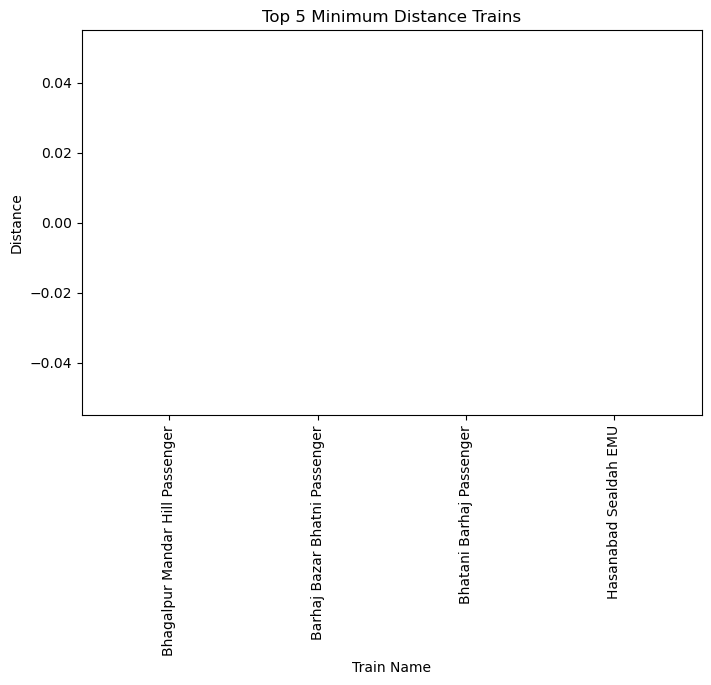

In [48]:
min_train = rail.nsmallest(5,"Distance")

plt.figure(figsize=(8,5))
plt.bar(min_train["TrainName"],min_train["Distance"])
plt.xticks(rotation=90)
plt.title("Top 5 Minimum Distance Trains")
plt.xlabel("Train Name")
plt.ylabel("Distance")
plt.show()

In [27]:
# Q4.Top 10 Source Stations

In [28]:
rail["Source"].value_counts().head(10)

Source
HOWRAH JN             136
CHENNAI BEACH         122
NEW DELHI              80
OLD DELHI              70
CHENNAI CENTRAL        68
BANGALORE CITY JN      57
AHMEDABAD JN           56
LINGAMPALLI            54
HYDERABAD DECCAN       53
DELHI H NIZAMUDDIN     51
Name: count, dtype: int64

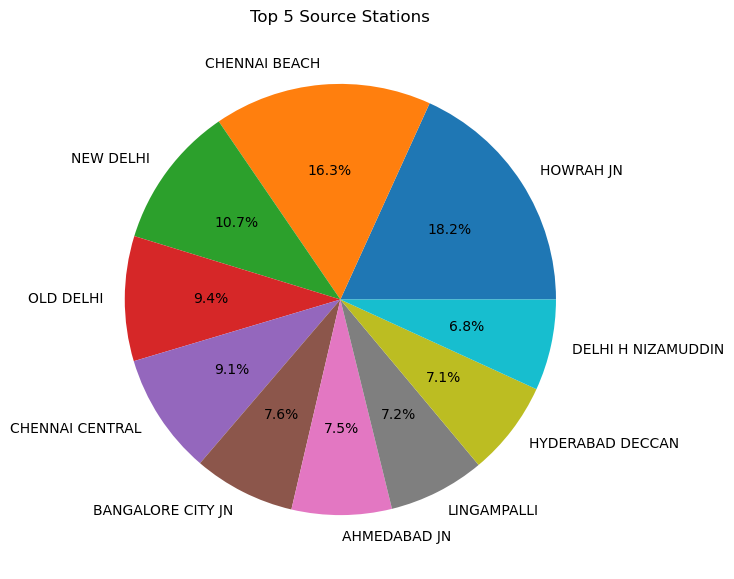

In [29]:
top5 = rail["Source"].value_counts().head(10)

plt.figure(figsize=(7,7))
plt.pie(top5,labels=top5.index,autopct="%1.1f%%")
plt.title("Top 5 Source Stations")
plt.show()

# BIVARIATE ANALYSIS

(Analysis using two columns)

In [30]:
# Q1. Which Source Stations have the highest average distance?

In [31]:
avg_dist = rail.groupby("Source")["Distance"].mean()

avg_dist.sort_values(ascending=False).head(10)

Source
DIBRUGARH              2553.100000
BANGALORE CANT         2258.000000
SANTRAGACHI JN         2127.500000
KOCHUVELI              2088.400000
PATLIPUTRA             2074.333333
GANDHIDHAM BG          1917.142857
OKHA                   1883.285714
KISHANGANJ             1835.000000
HAPA                   1758.000000
LOKMANYA TILAK TERM    1695.061224
Name: Distance, dtype: float64

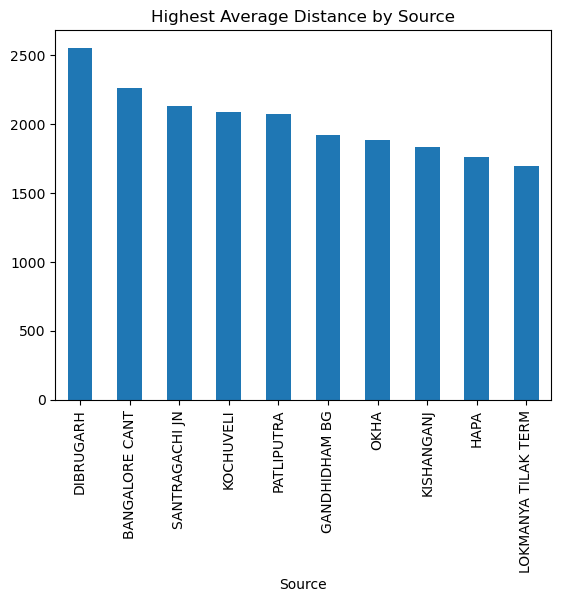

In [50]:
avg_dist.sort_values(ascending=False).head(10).plot(kind="bar")
plt.xticks(rotation=90)
plt.title("Highest Average Distance by Source")
plt.show()

In [33]:
# Q2. Which Source-Destination routes have the most trains?

In [34]:
route = rail.groupby(["Source","Destination"]).size()

route.sort_values(ascending=False).head(10)

Source               Destination        
CHENNAI BEACH        Velachery              70
LINGAMPALLI          KACHEGUDA FALAKNUMA    30
CHENNAI BEACH        TAMBARAM               29
KACHEGUDA FALAKNUMA  LINGAMPALLI            28
HYDERABAD DECCAN     LINGAMPALLI            26
LINGAMPALLI          HYDERABAD DECCAN       23
HOWRAH JN            PANSKURA               21
PANSKURA             HOWRAH JN              16
CHENNAI BEACH        CHENGALPATTU           14
BARDDHAMAN JN        ASANSOL JN              9
dtype: int64

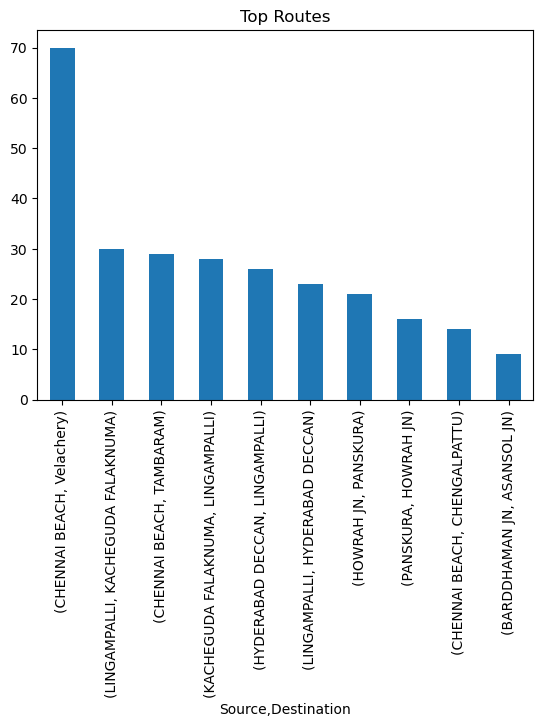

In [35]:
route.sort_values(ascending=False).head(10).plot(kind="bar")

plt.title("Top Routes")
plt.show()

In [36]:
# Q3. Which train covers the maximum distance?

In [37]:
rail.loc[rail["Distance"].idxmax(),["TrainName","Distance"]]

TrainName    KANNIYAKUMARI - DIBRUGARH Vivek Exp
Distance                                  4279.0
Name: 1560, dtype: object

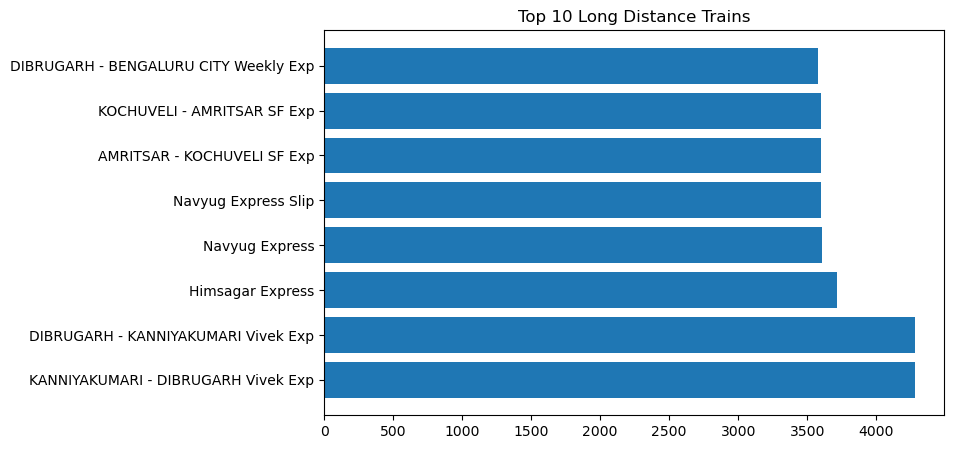

In [38]:
top_train = rail.nlargest(10,"Distance")

plt.figure(figsize=(8,5))
plt.barh(top_train["TrainName"],top_train["Distance"])
plt.title("Top 10 Long Distance Trains")
plt.show()

In [39]:
# Q4. Which Source Station has the maximum number of trains?

In [40]:
rail.groupby("Source")["TrainNumber"].count().sort_values(ascending=False).head(10)

Source
HOWRAH JN             136
CHENNAI BEACH         122
NEW DELHI              80
OLD DELHI              70
CHENNAI CENTRAL        68
BANGALORE CITY JN      57
AHMEDABAD JN           56
LINGAMPALLI            54
HYDERABAD DECCAN       53
DELHI H NIZAMUDDIN     51
Name: TrainNumber, dtype: int64

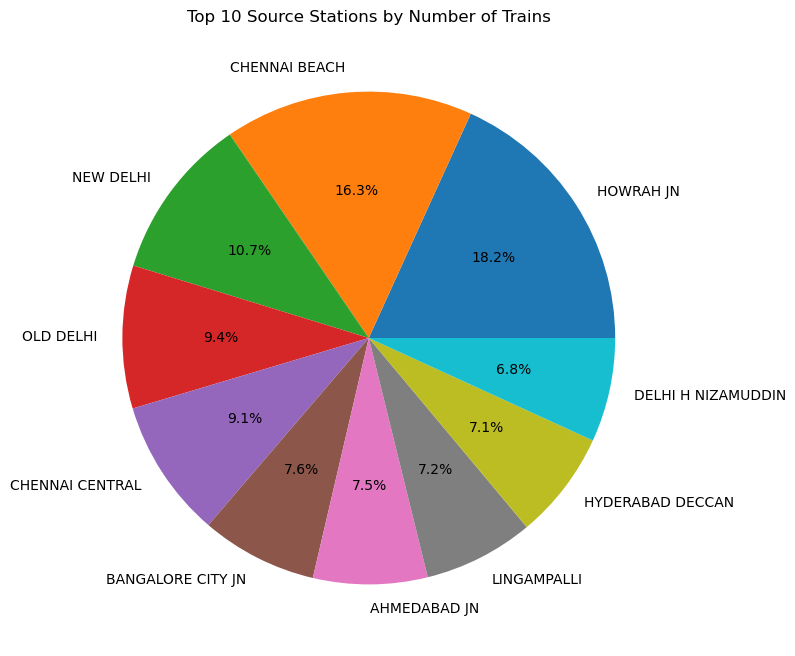

In [41]:
source_train = rail.groupby("Source")["TrainNumber"].count().sort_values(ascending=False).head(10)

plt.figure(figsize=(8,8))
plt.pie(source_train,labels=source_train.index,autopct="%1.1f%%")
plt.title("Top 10 Source Stations by Number of Trains")
plt.show()

# VISUALIZATION

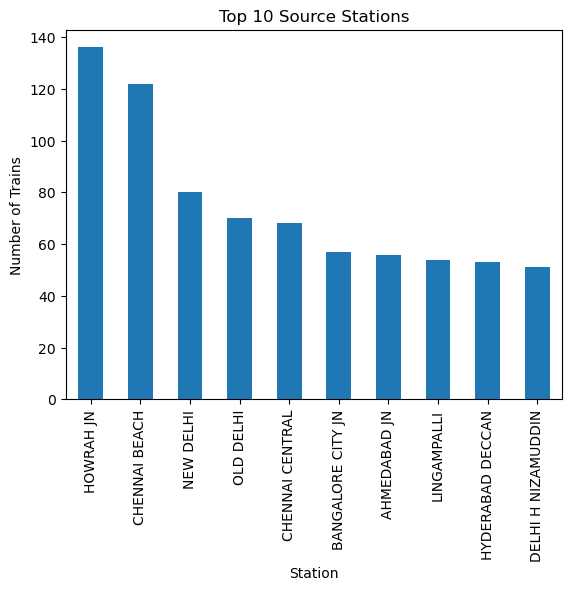

In [53]:
# Top 10 Source Stations (bar)

rail["Source"].value_counts().head(10).plot(kind="bar")
plt.xticks(rotation=90)
plt.title("Top 10 Source Stations")
plt.xlabel("Station")
plt.ylabel("Number of Trains")
plt.show()

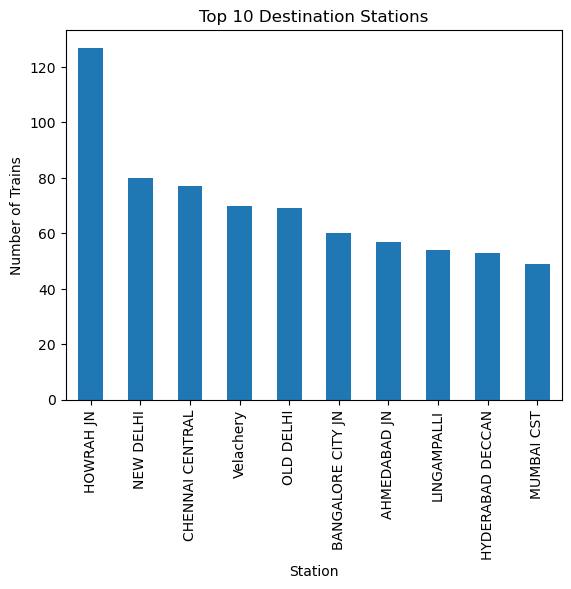

In [54]:
# Top 10 Destination Stations (bar)

rail["Destination"].value_counts().head(10).plot(kind="bar")
plt.title("Top 10 Destination Stations")
plt.xlabel("Station")
plt.ylabel("Number of Trains")
plt.show()

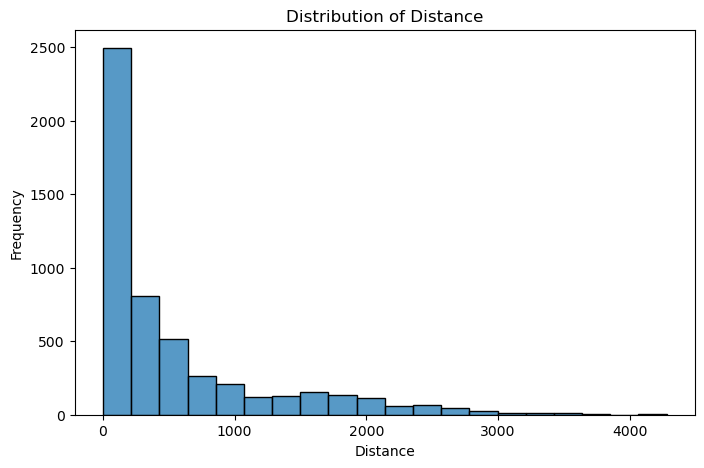

In [44]:
# Distance Distribution (Histogram)

plt.figure(figsize=(8,5))
sns.histplot(rail["Distance"], bins=20)
plt.title("Distribution of Distance")
plt.xlabel("Distance")
plt.ylabel("Frequency")
plt.show()

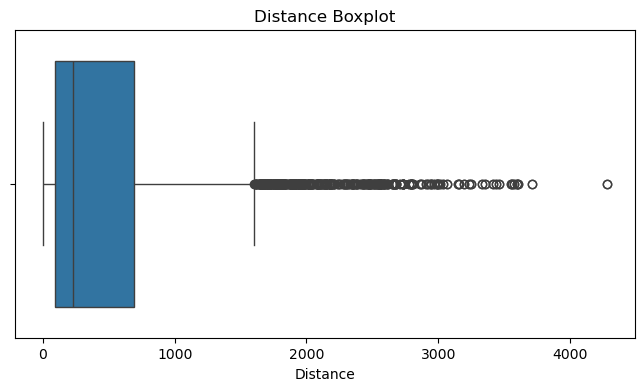

In [45]:
# Distance Spread (Boxplot)

plt.figure(figsize=(8,4))
sns.boxplot(x=rail["Distance"])
plt.title("Distance Boxplot")
plt.show()

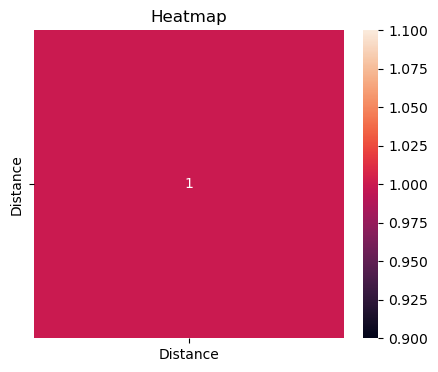

In [46]:
# Heatmap

corr = rail[["Distance"]].corr()
plt.figure(figsize=(5,4))
sns.heatmap(corr,annot=True)
plt.title("Heatmap")
plt.show()

# FINDINGS

Key Findings

1. The dataset contains more than 5000 train records.
2. The dataset contains only 1 max. distance train.
3. The datset contains more then 1 min. distance train.

In [47]:
print("Total Trains :",len(rail))
print("Maximum Distance :",rail["Distance"].max())
print("Minimum Distance :",rail["Distance"].min())

Total Trains : 5191
Maximum Distance : 4279.0
Minimum Distance : 0.0


# CONCLUSION

## Future Scope